# Climate Digital Twin: LSTM Weather Forecast Model Training

This notebook loads the processed daily climate dataset (2015-2025), prepares lag and time features, builds a Keras LSTM model, trains it on historical data (2015-2023), evaluates it on test data (2024-2025), and saves the trained model parameters to disk.

### 1. Import Dependencies and Load Data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Reshape
from sklearn.preprocessing import MinMaxScaler

# Set paths relative to notebooks/model_experiments/ directory
data_path = os.path.join("..", "..", "data", "processed", "climate_data.csv")
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
df.head(10)

,date,rainfall,tempmax,tempmin
0,2015-01-01,2.079576,23.000713,12.394957
1,2015-01-02,3.065960,23.127247,13.361515
2,2015-01-03,2.556801,22.923555,14.027359
3,2015-01-04,2.028095,23.492304,13.442063
4,2015-01-05,0.790108,23.630041,12.164774
5,2015-01-06,0.149564,24.124043,10.783683
6,2015-01-07,0.002898,24.113424,10.457525
7,2015-01-08,0.048878,23.900396,10.505843
8,2015-01-09,0.088837,23.619413,10.284516
9,2015-01-10,0.027455,23.738110,9.451249


### 2. Feature Engineering & Train-Test Split

We create helper time features (`dayofyear`, `month`) and define train/test boundary subsets.

In [2]:
df['dayofyear'] = df['date'].dt.dayofyear
df['month'] = df['date'].dt.month

train_df = df[df['date'] < '2024-01-01'].copy()
test_df = df[df['date'] >= '2024-01-01'].copy()

print(f"Train set: {len(train_df)} rows ({train_df['date'].min().strftime('%Y-%m-%d')} to {train_df['date'].max().strftime('%Y-%m-%d')})")
print(f"Test set: {len(test_df)} rows ({test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')})")

Train set: 3287 rows (2015-01-01 to 2023-12-31)
Test set: 731 rows (2024-01-01 to 2025-12-31)


### 3. Scaling & Sequence Data Preparation

We fit separate MinMaxScaler scalers on target features (`rainfall`, `tempmax`, `tempmin`) and helper time variables (`dayofyear`, `month`) to avoid data leakage. Then, we construct sliding window input vectors.

In [3]:
scaler_target = MinMaxScaler()
scaler_time = MinMaxScaler()

train_target_scaled = scaler_target.fit_transform(train_df[['rainfall', 'tempmax', 'tempmin']])
test_target_scaled = scaler_target.transform(test_df[['rainfall', 'tempmax', 'tempmin']])

train_time_scaled = scaler_time.fit_transform(train_df[['dayofyear', 'month']])
test_time_scaled = scaler_time.transform(test_df[['dayofyear', 'month']])

def create_sequences(target_data, time_data, seq_len=7, horizon=7):
    X, y = [], []
    n = len(target_data)
    for i in range(seq_len, n - horizon + 1):
        # Inputs: previous 7 days of scaled target and time features (shape: 7 x 5)
        seq_target = target_data[i - seq_len : i]
        seq_time = time_data[i - seq_len : i]
        seq_features = np.hstack([seq_target, seq_time])
        
        # Target: next 7 days of scaled rainfall, tempmax, tempmin (shape: 7 x 3)
        target = target_data[i : i + horizon]
        
        X.append(seq_features)
        y.append(target)
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_target_scaled, train_time_scaled)
X_test, y_test = create_sequences(test_target_scaled, test_time_scaled)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (3274, 7, 5)
y_train shape: (3274, 7, 3)


### 4. Build and Train the LSTM Model

We use a Sequential model with an LSTM layer, a Dense layer, and a Reshape layer to structure outputs directly into the dynamic 7-day forecast.

In [4]:
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(7, 5), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(21), # 7 days * 3 parameters
    Reshape((7, 3))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

c:\Users\karti\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │           693 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 3)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,693 (80.83 KB)

 Trainable params: 20,693 (80.83 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0821 - val_loss: 0.0136
Epoch 2/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0104 - val_loss: 0.0086
Epoch 3/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0065 - val_loss: 0.0073
Epoch 4/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0061 - val_loss: 0.0072
Epoch 5/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0060 - val_loss: 0.0070
Epoch 6/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0057 - val_loss: 0.0074
Epoch 7/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0058 - val_loss: 0.0068
Epoch 8/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 - val_loss: 0.0076
Epoch 9/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0055 - val_loss: 0.0070
Epoch 10/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0055 - val_loss: 0.0063
Epoch 11/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0053 - val_loss: 0.0081
Epoch 12/15
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0055 - val_lo

### 5. Model Evaluation & Inversing Scales

We calculate the Root Mean Squared Error (RMSE) for each forecasted climate variable on the test set.

In [5]:
y_pred = model.predict(X_test)

# Inverse transform values to original scales
y_pred_orig = scaler_target.inverse_transform(y_pred.reshape(-1, 3)).reshape(y_pred.shape)
y_test_orig = scaler_target.inverse_transform(y_test.reshape(-1, 3)).reshape(y_test.shape)

rmse_rain = np.sqrt(np.mean((y_test_orig[:, :, 0] - y_pred_orig[:, :, 0])**2))
rmse_tmax = np.sqrt(np.mean((y_test_orig[:, :, 1] - y_pred_orig[:, :, 1])**2))
rmse_tmin = np.sqrt(np.mean((y_test_orig[:, :, 2] - y_pred_orig[:, :, 2])**2))

print(f"Test Set RMSE:")
print(f"  Rainfall: {rmse_rain:.4f} mm")
print(f"  Temp Max: {rmse_tmax:.4f}°C")
print(f"  Temp Min: {rmse_tmin:.4f}°C")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Test Set RMSE:
  Rainfall: 1.7821 mm
  Temp Max: 1.0076°C
  Temp Min: 1.0487°C


### 6. Plotting Predicted vs Actual Timelines

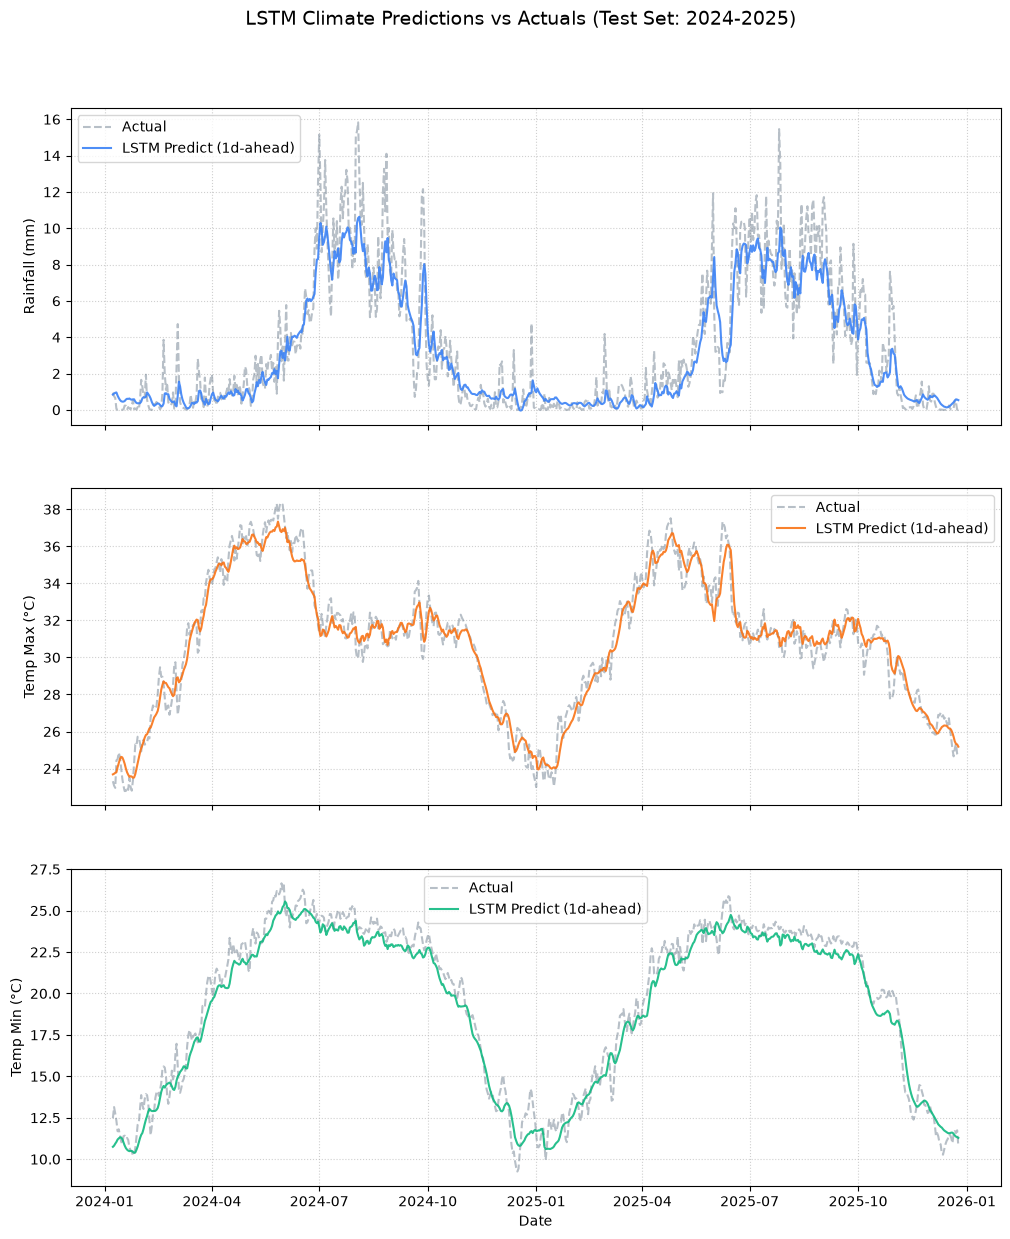

In [6]:
actual_1d = y_test_orig[:, 0, :]
pred_1d = y_pred_orig[:, 0, :]
test_dates = test_df['date'].iloc[7 : 7 + len(actual_1d)].values

fig, axes = plt.subplots(3, 1, figsize=(12, 14), sharex=True)

variables = [('Rainfall (mm)', '#3b82f6'), ('Temp Max (°C)', '#f97316'), ('Temp Min (°C)', '#10b981')]
for idx, (label, color) in enumerate(variables):
    axes[idx].plot(test_dates, actual_1d[:, idx], label='Actual', color='slategray', alpha=0.5, linestyle='--')
    axes[idx].plot(test_dates, pred_1d[:, idx], label='LSTM Predict (1d-ahead)', color=color, alpha=0.9)
    axes[idx].set_ylabel(label)
    axes[idx].legend()
    axes[idx].grid(True, linestyle=':', alpha=0.6)
    
axes[2].set_xlabel('Date')
plt.suptitle('LSTM Climate Predictions vs Actuals (Test Set: 2024-2025)', fontsize=14, y=0.95)
plt.show()

### 7. Export Model Parameters

In [7]:
model_dir = os.path.join("..", "..", "models", "saved_models")
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "climate_lstm_model.h5")

print(f"Saving trained model parameters to: {model_path}...")
model.save(model_path)
print("Success!")

Saving trained model parameters to: ..\..\models\saved_models\climate_lstm_model.h5...
Success!
